# Progressive-noise sanity check: cumulative whole-trajectory familiarity

## Research question

Take two independent nominal trajectory populations generated by the same mature CartPole policy:

- a clean nominal reference population
- a nominal query population with progressive Gaussian noise applied to one dimension

We look at the cumulative temporal similarity in the query population to the reference population to see if the similarity drops off as expected.


In [12]:
from __future__ import annotations

from dataclasses import fields, is_dataclass
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr

from cartpole_idk.artifacts import FitArtifact, EmbeddingArtifact

try:
    from pyidk import SequenceBatch
except ImportError:
    from pyidk.data import SequenceBatch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ROOT = Path.cwd().resolve()
for _ in range(4):
    if (ROOT / "pyproject.toml").exists():
        break
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Run from the cartpole-idk repository or notebooks directory.")

# ---------------------------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------------------------

# Independent clean nominal prepared population.
REFERENCE_DATASET_DIR = ROOT / "datasets/prepared/200000-iter_nominal_100_episodes"

# A DIFFERENT nominal prepared population after progressive-noise injection.
NOISY_DATASET_DIR = ROOT / "datasets/prepared/200000-iter_nominal_100_episodes_2_theta_noise"

# Existing whole-mode embeddings. These are not used to create the time curve;
# they are used only to verify that the k=100 prefix implementation reproduces
# the ordinary whole-trajectory pipeline.
REFERENCE_WHOLE_ARTIFACT_DIR = ROOT / (
    "artifacts/embeddings/200000-iter_nominal_500_episodes/"
    "psi-32_t-100_vanilla-state/200K-nom-100ep/whole"
)
NOISY_WHOLE_ARTIFACT_DIR = ROOT / (
    "artifacts/embeddings/200000-iter_nominal_500_episodes/"
    "psi-32_t-100_vanilla-state/"
    "200000-iter_nominal_100_episodes_2_theta_noise/whole"
)

# The fitted scaler + IDK basis used to produce BOTH whole embedding artifacts.
# The code tries a few common project layouts. If none exists, set this explicitly.
FIT_ARTIFACT_CANDIDATES = [
    ROOT / (
        "artifacts/fits/200000-iter_nominal_500_episodes/"
        "psi-32_t-100_vanilla-state"
    ),
    ROOT / (
        "artifacts/fit/200000-iter_nominal_500_episodes/"
        "psi-32_t-100_vanilla-state"
    ),
]
FIT_ARTIFACT_DIR = next(
    (p for p in FIT_ARTIFACT_CANDIDATES if (p / "config.json").exists()),
    FIT_ARTIFACT_CANDIDATES[0],
)

# Population familiarity summaries.
TOP_K = 5

# Analyze every transition count by default: k = 1, ..., 100.
# Increase to 2/5/etc. if you later want a coarser diagnostic.
PREFIX_STRIDE = 1

# Bootstrap resamples complete query trajectories.
N_BOOTSTRAP = 1000
SEED = 42

# Numerical tolerance for reproducing the saved whole embedding at k=T.
ENDPOINT_ATOL = 1e-12


## 1. Load the fit artifact and recover the fitted scaler / IDK model

`FitArtifact.load(...)` reconstructs the saved fitted objects without refitting. The small resolver below is deliberately defensive about the artifact's internal attribute names; it searches the loaded object graph for:

- the fitted standardizer (`mean_`, `scale_`, `transform`);
- the fitted `IsolationDistributionalKernel` (`point_kernel`, `transform`, `similarity`).

Nothing is refit in this notebook.


In [13]:
if not FIT_ARTIFACT_DIR.exists():
    raise FileNotFoundError(
        "Could not locate the fit artifact automatically. Set FIT_ARTIFACT_DIR to the "
        "directory containing config.json, scaler.npz, basis.npz, and metadata.json.\n"
        f"Tried: {[str(p) for p in FIT_ARTIFACT_CANDIDATES]}"
    )

fit_artifact = FitArtifact.load(FIT_ARTIFACT_DIR)

def _iter_children(obj):
    """Yield shallow child objects without walking arrays/dataframes/primitive leaves."""
    if obj is None:
        return

    if isinstance(obj, dict):
        for key, value in obj.items():
            yield str(key), value
        return

    if isinstance(obj, (str, bytes, int, float, bool, Path, np.ndarray, pd.DataFrame, pd.Series)):
        return

    names = set()

    if is_dataclass(obj):
        names.update(field.name for field in fields(obj))

    if hasattr(obj, "__dict__"):
        names.update(vars(obj).keys())

    slots = getattr(type(obj), "__slots__", ())
    if isinstance(slots, str):
        slots = (slots,)
    names.update(slots)

    # Common artifact-wrapper names even when slots/__dict__ are hidden.
    names.update({
        "scaler", "standardizer", "preprocessor",
        "idk", "kernel", "model", "distributional_kernel",
        "reference", "fitted", "fit",
    })

    for name in names:
        if not name or str(name).startswith("_"):
            continue
        try:
            value = getattr(obj, name)
        except Exception:
            continue
        if callable(value):
            continue
        yield str(name), value

def find_component(root, predicate, *, max_depth=4):
    queue = [(root, 0, "fit_artifact")]
    visited = set()

    while queue:
        obj, depth, path = queue.pop(0)
        obj_id = id(obj)
        if obj_id in visited:
            continue
        visited.add(obj_id)

        try:
            if predicate(obj):
                return obj, path
        except Exception:
            pass

        if depth >= max_depth:
            continue

        for name, child in _iter_children(obj):
            queue.append((child, depth + 1, f"{path}.{name}"))

    return None, None

scaler, scaler_path = find_component(
    fit_artifact,
    lambda obj: (
        hasattr(obj, "transform")
        and hasattr(obj, "mean_")
        and hasattr(obj, "scale_")
    ),
)

idk_model, idk_path = find_component(
    fit_artifact,
    lambda obj: (
        hasattr(obj, "transform")
        and hasattr(obj, "similarity")
        and hasattr(obj, "point_kernel")
    ),
)

if scaler is None:
    raise RuntimeError(
        "Could not locate the fitted Standardizer inside FitArtifact. "
        "Inspect FitArtifact.load(FIT_ARTIFACT_DIR) and update the resolver."
    )
if idk_model is None:
    raise RuntimeError(
        "Could not locate the fitted IsolationDistributionalKernel inside FitArtifact. "
        "Inspect FitArtifact.load(FIT_ARTIFACT_DIR) and update the resolver."
    )

embedding_dim = idk_model.point_kernel.n_embedding_features
if callable(embedding_dim):
    embedding_dim = embedding_dim()

print(f"Fit artifact: {FIT_ARTIFACT_DIR}")
print(f"Scaler found at: {scaler_path} ({type(scaler).__name__})")
print(f"IDK model found at: {idk_path} ({type(idk_model).__name__})")
print(
    "IDK:",
    f"t={idk_model.point_kernel.n_partitions},",
    f"psi={idk_model.point_kernel.samples_per_partition},",
    f"embedding_dim={embedding_dim}",
)

fit_config_dict = fit_artifact.config.model_dump(mode="json")
display(pd.Series(fit_config_dict, name="value").to_frame())


Fit artifact: /Users/dma0523/code/research/cartpole-idk/artifacts/fit/200000-iter_nominal_500_episodes/psi-32_t-100_vanilla-state
Scaler found at: fit_artifact.scaler (Standardizer)
IDK model found at: fit_artifact.model (IsolationDistributionalKernel)
IDK: t=100, psi=32, embedding_dim=3200


,value
dataset,/Users/dma0523/code/research/cartpole-idk/data...
trajectory_ids,"[traj_20260921T123642747196Z_86707dd2, traj_20..."
idk,"{'representation': 'state', 'observation_sourc..."
unit,"{'mode': 'whole', 'window_length': 25, 'stride..."


## 2. Recover representation settings from the fit configuration

The cumulative prefixes must be transformed exactly as the original fitting/embedding pipeline expects.

For the current `vanilla-state` experiment, a prefix containing $k$ transitions contains $k+1$ state observations.


In [14]:
def recursive_values_for_key(obj, target_key):
    found = []

    def visit(node):
        if isinstance(node, dict):
            for key, value in node.items():
                if key == target_key:
                    found.append(value)
                visit(value)
        elif isinstance(node, list):
            for value in node:
                visit(value)

    visit(obj)
    return found

def first_scalar_config_value(keys, default=None):
    for key in keys:
        values = recursive_values_for_key(fit_config_dict, key)
        for value in values:
            if isinstance(value, (str, int, float, bool)) or value is None:
                return value
    return default

representation = first_scalar_config_value(("representation",))
if representation is None:
    raise KeyError("Could not find `representation` in the fit configuration.")

representation = str(representation).lower().replace("_", "-")

observation_source = str(
    first_scalar_config_value(("observation_source", "observation-source"), "true")
).lower()

action_source = str(
    first_scalar_config_value(("action_source", "action-source"), "executed")
).lower()

representation_window_length = first_scalar_config_value(
    ("representation_window_length", "representation-window-length"),
    None,
)
if representation_window_length is not None:
    representation_window_length = int(representation_window_length)

OBS_KEY = {
    "true": "true_observations",
    "true-observations": "true_observations",
    "agent": "agent_observations",
    "agent-observations": "agent_observations",
}.get(observation_source)

ACTION_KEY = {
    "commanded": "commanded_actions",
    "commanded-actions": "commanded_actions",
    "executed": "executed_actions",
    "executed-actions": "executed_actions",
}.get(action_source)

if OBS_KEY is None:
    raise ValueError(f"Unsupported observation source: {observation_source!r}")
if ACTION_KEY is None:
    raise ValueError(f"Unsupported action source: {action_source!r}")

SUPPORTED_REPRESENTATIONS = {
    "state",
    "transition",
    "state-action",
    "state-action-next-state",
    "temporal-window",
    "window",
}
if representation not in SUPPORTED_REPRESENTATIONS:
    raise ValueError(
        f"Unsupported representation {representation!r}; "
        f"supported here: {sorted(SUPPORTED_REPRESENTATIONS)}"
    )

if representation in {"temporal-window", "window"} and not representation_window_length:
    raise ValueError(
        "Temporal-window representation requires representation_window_length in the fit config."
    )

print("Representation:", representation)
print("Observation source:", OBS_KEY)
print("Action source:", ACTION_KEY)
print("Representation-window length:", representation_window_length)
print("Scaler feature count:", len(np.asarray(scaler.mean_)))


Representation: state
Observation source: true_observations
Action source: executed_actions
Representation-window length: None
Scaler feature count: 4


## 3. Load the two independent prepared trajectory populations

The clean reference and noisy query populations must be separate trajectory draws.

The noisy dataset's `noise_injection.json` is also loaded here, which describes the noise that has been added to the original dataset.

In [15]:
def load_prepared_dataset(directory: Path):
    paths = sorted(directory.rglob("traj_*.npz"))
    if not paths:
        raise FileNotFoundError(f"No traj_*.npz files found under {directory}")

    records = []
    for path in paths:
        with np.load(path, allow_pickle=False) as archive:
            required = {
                "trajectory_id",
                OBS_KEY,
                ACTION_KEY,
                "metadata_json",
            }
            missing = required - set(archive.files)
            if missing:
                raise ValueError(f"{path}: missing keys {sorted(missing)}")

            observations = np.asarray(archive[OBS_KEY], dtype=float)
            actions = np.asarray(archive[ACTION_KEY])
            metadata = json.loads(str(archive["metadata_json"].item()))
            trajectory_id = str(archive["trajectory_id"].item())

        if observations.ndim != 2 or observations.shape[1] != 4:
            raise ValueError(f"{path}: expected observations shape (N, 4), got {observations.shape}")
        if len(observations) != len(actions) + 1:
            raise ValueError(
                f"{path}: expected T+1 observations for T actions; "
                f"got {len(observations)} observations and {len(actions)} actions"
            )

        records.append({
            "path": path,
            "relative_path": path.relative_to(directory),
            "trajectory_id": trajectory_id,
            "source_trajectory_id": str(metadata.get("source_trajectory_id", trajectory_id)),
            "observations": observations,
            "actions": actions,
            "metadata": metadata,
            "n_steps": len(actions),
        })

    return records

reference_trajectories = load_prepared_dataset(REFERENCE_DATASET_DIR)
noisy_trajectories = load_prepared_dataset(NOISY_DATASET_DIR)

reference_steps = sorted({record["n_steps"] for record in reference_trajectories})
noisy_steps = sorted({record["n_steps"] for record in noisy_trajectories})

if len(reference_steps) != 1 or len(noisy_steps) != 1:
    raise ValueError(
        "This sanity check expects fixed-length prepared trajectories. "
        f"Reference lengths={reference_steps}; noisy lengths={noisy_steps}"
    )
if reference_steps != noisy_steps:
    raise ValueError(
        f"Reference and noisy trajectory lengths differ: {reference_steps} vs {noisy_steps}"
    )

N_STEPS = reference_steps[0]

reference_ids = {record["source_trajectory_id"] for record in reference_trajectories}
noisy_ids = {record["source_trajectory_id"] for record in noisy_trajectories}
overlap = reference_ids & noisy_ids
if overlap:
    raise ValueError(
        f"Reference and noisy query populations share {len(overlap)} source trajectory IDs. "
        "Use independent nominal trajectory populations for this experiment."
    )

noise_config_path = NOISY_DATASET_DIR / "noise_injection.json"
if not noise_config_path.exists():
    raise FileNotFoundError(f"Missing {noise_config_path}")
noise_config = json.loads(noise_config_path.read_text())

noise_dimension = int(noise_config["dimension"])
noise_dimension_name = str(noise_config["dimension_name"])
noise_start_std = float(noise_config["start_std"])
noise_end_std = float(noise_config["end_std"])
noise_onset = int(noise_config["onset"])
noise_power = float(noise_config["power"])

target = str(noise_config.get("target", "both"))
if target == "true" and OBS_KEY != "true_observations":
    raise ValueError(
        "Noise was injected only into true_observations, but the fit uses agent_observations."
    )
if target == "agent" and OBS_KEY != "agent_observations":
    raise ValueError(
        "Noise was injected only into agent_observations, but the fit uses true_observations."
    )

print(f"Reference trajectories: {len(reference_trajectories)}")
print(f"Noisy query trajectories: {len(noisy_trajectories)}")
print(f"Prepared length: {N_STEPS} transitions / {N_STEPS + 1} observations")
print(
    f"Progressive noise: {noise_dimension_name}, "
    f"sigma {noise_start_std:g} -> {noise_end_std:g}, "
    f"onset={noise_onset}, power={noise_power:g}"
)


Reference trajectories: 100
Noisy query trajectories: 100
Prepared length: 100 transitions / 101 observations
Progressive noise: theta, sigma 0 -> 0.25, onset=0, power=1


## 4. Verify that the realized noise actually increases through time

For each noisy query trajectory, compare it to **its own pre-noise source copy** from `noise_injection.json["input_dir"]`.

This is only a transformation check. The IDK experiment below still compares the noisy query population to the separate clean nominal reference population.

The requested standard-deviation envelope is monotonic, but individual Gaussian draws are not. Across many trajectories, the realized RMS noise should track the requested envelope.


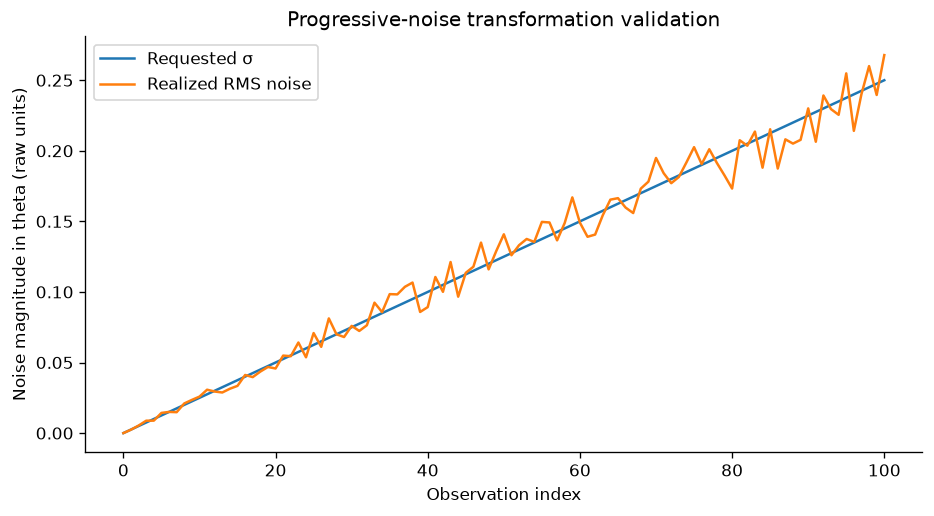

Spearman rho(requested sigma, realized RMS noise) = 0.9920 (p=1.06e-90)


In [16]:
source_query_dir = Path(noise_config["input_dir"])
if not source_query_dir.exists():
    raise FileNotFoundError(
        "The original pre-noise query dataset recorded in noise_injection.json "
        f"does not exist: {source_query_dir}"
    )

def requested_sigma(n_observations):
    sigma = np.zeros(n_observations, dtype=float)
    if not 0 <= noise_onset < n_observations:
        raise ValueError(
            f"Noise onset {noise_onset} is outside {n_observations} observations."
        )

    remaining = n_observations - noise_onset
    if remaining == 1:
        sigma[noise_onset] = noise_end_std
    else:
        phase = np.linspace(0.0, 1.0, remaining)
        sigma[noise_onset:] = (
            noise_start_std
            + (noise_end_std - noise_start_std) * phase**noise_power
        )
    return sigma

sigma = requested_sigma(N_STEPS + 1)

raw_rows = []
for record in noisy_trajectories:
    source_path = source_query_dir / record["relative_path"]
    if not source_path.exists():
        raise FileNotFoundError(
            f"Cannot validate injected noise; missing source counterpart: {source_path}"
        )

    with np.load(source_path, allow_pickle=False) as source_npz:
        source_obs = np.asarray(source_npz[OBS_KEY], dtype=float)

    noisy_obs = record["observations"]
    if source_obs.shape != noisy_obs.shape:
        raise ValueError(
            f"{record['relative_path']}: source/noisy observation shapes differ: "
            f"{source_obs.shape} vs {noisy_obs.shape}"
        )

    delta = noisy_obs[:, noise_dimension] - source_obs[:, noise_dimension]
    for step, value in enumerate(delta):
        raw_rows.append({
            "trajectory_id": record["trajectory_id"],
            "step": step,
            "requested_sigma": sigma[step],
            "noise": float(value),
            "squared_noise": float(value * value),
        })

raw_noise = pd.DataFrame(raw_rows)
raw_curve = (
    raw_noise.groupby("step", as_index=False)
    .agg(
        requested_sigma=("requested_sigma", "first"),
        rms_noise=("squared_noise", lambda x: float(np.sqrt(np.mean(x)))),
        mean_abs_noise=("noise", lambda x: float(np.mean(np.abs(x)))),
        n=("noise", "size"),
    )
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(raw_curve["step"], raw_curve["requested_sigma"], label="Requested σ")
ax.plot(raw_curve["step"], raw_curve["rms_noise"], label="Realized RMS noise")
ax.set_xlabel("Observation index")
ax.set_ylabel(f"Noise magnitude in {noise_dimension_name} (raw units)")
ax.set_title("Progressive-noise transformation validation")
ax.legend()
plt.show()

raw_rho = spearmanr(
    raw_curve["requested_sigma"],
    raw_curve["rms_noise"],
    nan_policy="omit",
)
print(
    "Spearman rho(requested sigma, realized RMS noise) = "
    f"{raw_rho.statistic:.4f} (p={raw_rho.pvalue:.3g})"
)


## 5. Construct cumulative representation prefixes

`k` is the number of CartPole transitions observed so far.

The full representation sequence is then standardized using the **saved fit scaler**, and the saved fitted IDK transforms the sequence with mean aggregation.

No scaler or IDK basis is fit here.


In [17]:
def build_representation_rows(record, k):
    """Return the representation rows induced by the first k transitions."""
    obs = record["observations"]
    actions = record["actions"]

    if not 1 <= k <= record["n_steps"]:
        raise ValueError(f"k must be in [1, {record['n_steps']}], got {k}")

    if representation == "state":
        return obs[: k + 1]

    if representation == "transition":
        return np.concatenate([obs[:k], obs[1 : k + 1]], axis=1)

    if representation == "state-action":
        return np.concatenate(
            [obs[:k], actions[:k].reshape(-1, 1)],
            axis=1,
        )

    if representation == "state-action-next-state":
        return np.concatenate(
            [
                obs[:k],
                actions[:k].reshape(-1, 1),
                obs[1 : k + 1],
            ],
            axis=1,
        )

    if representation in {"temporal-window", "window"}:
        length = representation_window_length
        prefix_obs = obs[: k + 1]
        if len(prefix_obs) < length:
            return np.empty((0, length * obs.shape[1]), dtype=float)
        return np.stack(
            [
                prefix_obs[start : start + length].reshape(-1)
                for start in range(len(prefix_obs) - length + 1)
            ]
        )

    raise AssertionError(f"Unhandled representation: {representation}")

def standardize_representation(rows):
    """Apply the saved scaler at the same feature level it was fit on."""
    rows = np.asarray(rows, dtype=float)
    scaler_dim = len(np.asarray(scaler.mean_))

    if rows.shape[1] == scaler_dim:
        return scaler.transform(rows)

    # Some pipelines standardize the 4-D state first and then concatenate
    # state-derived temporal features. Support that case for state/transition
    # representations. The final whole-artifact sanity check below will catch
    # any mismatch with the actual project pipeline.
    if scaler_dim == 4 and representation == "transition" and rows.shape[1] == 8:
        left = scaler.transform(rows[:, :4])
        right = scaler.transform(rows[:, 4:8])
        return np.concatenate([left, right], axis=1)

    raise ValueError(
        f"Representation has {rows.shape[1]} features but scaler has {scaler_dim}. "
        "The notebook cannot safely infer this preprocessing path."
    )

def embed_population_prefix(trajectories, k):
    standardized_sequences = []

    for record in trajectories:
        rows = build_representation_rows(record, k)
        if len(rows) == 0:
            raise ValueError(
                f"Prefix k={k} is too short for representation {representation!r}."
            )
        standardized_sequences.append(standardize_representation(rows))

    standardized_batch = SequenceBatch.from_sequences(standardized_sequences)
    return idk_model.transform(standardized_batch, aggregation="mean")

# Earliest transition count that produces at least one representation row.
MIN_PREFIX_K = 1
if representation in {"temporal-window", "window"}:
    MIN_PREFIX_K = representation_window_length - 1

PREFIX_STEPS = np.arange(MIN_PREFIX_K, N_STEPS + 1, PREFIX_STRIDE, dtype=int)
if PREFIX_STEPS[-1] != N_STEPS:
    PREFIX_STEPS = np.append(PREFIX_STEPS, N_STEPS)

print(
    f"Evaluating {len(PREFIX_STEPS)} cumulative prefixes: "
    f"k={PREFIX_STEPS[0]}..{PREFIX_STEPS[-1]}"
)


Evaluating 100 cumulative prefixes: k=1..100


## 6. Compute cumulative population familiarity at every prefix

For each prefix $k$:

1. Embed all clean reference prefixes.
2. Embed all noisy query prefixes.
3. Compute noisy-query $\rightarrow$ clean-reference native IDK similarity.
4. Compute a clean nominal leave-one-out baseline at the same $k$.

For noisy query trajectory $i$:

$$
S_i(k)
=
\frac{1}{N_R}
\sum_{j=1}^{N_R}
K_{\mathrm{IDK}}
\left(
\mu^{Q_i}_{1:k},
\mu^{R_j}_{1:k}
\right)
$$

where $N_R$ is the number of clean reference trajectories.

We also compute top-$K$ nominal similarity as a secondary measure of similarity to the nearest familiar nominal trajectories.

Because cumulative prefixes retain earlier low-noise observations, accumulated noise severity is summarized using RMS noise:

$$
\sigma_{\mathrm{cum}}(k)
=
\sqrt{
\frac{1}{k+1}
\sum_{t=0}^{k} \sigma_t^2
}
$$

for the state representation.

In [19]:
def row_topk_mean(matrix, k):
    matrix = np.asarray(matrix, dtype=float)
    output = np.full(matrix.shape[0], np.nan)

    for i, row in enumerate(matrix):
        finite = row[np.isfinite(row)]
        if finite.size == 0:
            continue
        kk = min(k, finite.size)
        output[i] = np.mean(np.partition(finite, finite.size - kk)[-kk:])

    return output

def cumulative_sigma_rms(k):
    # Prefix of k transitions contains state observations 0..k.
    values = sigma[: k + 1]
    return float(np.sqrt(np.mean(values * values)))

query_rows = []
curve_rows = []

final_reference_from_loop = None
final_noisy_from_loop = None

for iteration, k in enumerate(PREFIX_STEPS, start=1):
    reference_prefix = embed_population_prefix(reference_trajectories, int(k))
    noisy_prefix = embed_population_prefix(noisy_trajectories, int(k))

    if k == N_STEPS:
        final_reference_from_loop = reference_prefix
        final_noisy_from_loop = noisy_prefix

    # Native IDK similarities from the reconstructed fitted model.
    query_to_reference = np.asarray(
        idk_model.similarity(noisy_prefix, reference_prefix, dense=True),
        dtype=float,
    )
    reference_to_reference = np.asarray(
        idk_model.similarity(reference_prefix, reference_prefix, dense=True),
        dtype=float,
    )

    query_mean = query_to_reference.mean(axis=1)
    query_topk = row_topk_mean(query_to_reference, TOP_K)

    # Leave-one-out clean nominal baseline.
    np.fill_diagonal(reference_to_reference, np.nan)
    baseline_mean = np.nanmean(reference_to_reference, axis=1)
    baseline_topk = row_topk_mean(reference_to_reference, TOP_K)

    for i, score in enumerate(query_mean):
        query_rows.append({
            "trajectory_id": noisy_trajectories[i]["source_trajectory_id"],
            "k": int(k),
            "end_sigma": float(sigma[min(int(k), len(sigma) - 1)]),
            "cumulative_sigma_rms": cumulative_sigma_rms(int(k)),
            "mean_nominal_similarity": float(score),
            "topk_nominal_similarity": float(query_topk[i]),
        })

    clean_mean = float(np.mean(baseline_mean))
    clean_topk = float(np.mean(baseline_topk))
    noisy_mean = float(np.mean(query_mean))
    noisy_topk_mean = float(np.mean(query_topk))

    curve_rows.append({
        "k": int(k),
        "end_sigma": float(sigma[min(int(k), len(sigma) - 1)]),
        "cumulative_sigma_rms": cumulative_sigma_rms(int(k)),
        "clean_mean_similarity": clean_mean,
        "noisy_mean_similarity": noisy_mean,
        "mean_similarity_ratio": noisy_mean / clean_mean if clean_mean != 0 else np.nan,
        "clean_topk_similarity": clean_topk,
        "noisy_topk_similarity": noisy_topk_mean,
        "topk_similarity_ratio": noisy_topk_mean / clean_topk if clean_topk != 0 else np.nan,
        "noisy_q25": float(np.quantile(query_mean, 0.25)),
        "noisy_median": float(np.median(query_mean)),
        "noisy_q75": float(np.quantile(query_mean, 0.75)),
    })

    if iteration == 1 or iteration % 10 == 0 or k == N_STEPS:
        print(f"Completed prefix k={k} ({iteration}/{len(PREFIX_STEPS)})")

query_scores = pd.DataFrame(query_rows)
curve = pd.DataFrame(curve_rows)

display(curve.head().round(6))
display(curve.tail().round(6))


Completed prefix k=1 (1/100)
Completed prefix k=10 (10/100)
Completed prefix k=20 (20/100)
Completed prefix k=30 (30/100)
Completed prefix k=40 (40/100)
Completed prefix k=50 (50/100)
Completed prefix k=60 (60/100)
Completed prefix k=70 (70/100)
Completed prefix k=80 (80/100)
Completed prefix k=90 (90/100)
Completed prefix k=100 (100/100)


,k,end_sigma,cumulative_sigma_rms,clean_mean_similarity,noisy_mean_similarity,mean_similarity_ratio,clean_topk_similarity,noisy_topk_similarity,topk_similarity_ratio,noisy_q25,noisy_median,noisy_q75
0,1,0.0025,0.001768,0.031674,0.028586,0.902498,0.241375,0.219045,0.907488,0.018150,0.023650,0.033812
1,2,0.0050,0.003227,0.032041,0.028961,0.903858,0.242953,0.217484,0.895170,0.018656,0.024261,0.035811
2,3,0.0075,0.004677,0.031818,0.028560,0.897605,0.232464,0.207079,0.890800,0.017559,0.022962,0.033603
3,4,0.0100,0.006124,0.031840,0.028646,0.899694,0.229708,0.204214,0.889014,0.018807,0.023340,0.035751
4,5,0.0125,0.007569,0.031471,0.028360,0.901150,0.221270,0.197303,0.891683,0.018358,0.022856,0.035815


,k,end_sigma,cumulative_sigma_rms,clean_mean_similarity,noisy_mean_similarity,mean_similarity_ratio,clean_topk_similarity,noisy_topk_similarity,topk_similarity_ratio,noisy_q25,noisy_median,noisy_q75
95,96,0.2400,0.138924,0.020421,0.007237,0.354402,0.051965,0.017533,0.337402,0.006453,0.007248,0.007898
96,97,0.2425,0.140368,0.020460,0.007166,0.350240,0.052026,0.017280,0.332140,0.006400,0.007182,0.007815
97,98,0.2450,0.141811,0.020510,0.007108,0.346558,0.052097,0.017039,0.327063,0.006377,0.007110,0.007746
98,99,0.2475,0.143255,0.020558,0.007048,0.342828,0.052196,0.016795,0.321772,0.006372,0.007069,0.007596
99,100,0.2500,0.144698,0.020596,0.006986,0.339199,0.052236,0.016571,0.317228,0.006347,0.006996,0.007491


## 7. Familiarity curves

The first plot shows raw native IDK familiarity.

The second divides noisy familiarity by the clean nominal leave-one-out baseline at the same prefix length. This helps distinguish a true noise effect from ordinary changes in how homogeneous the nominal population is as more of the trajectory is accumulated.

The third plots the baseline-normalized familiarity directly against cumulative RMS noise severity.


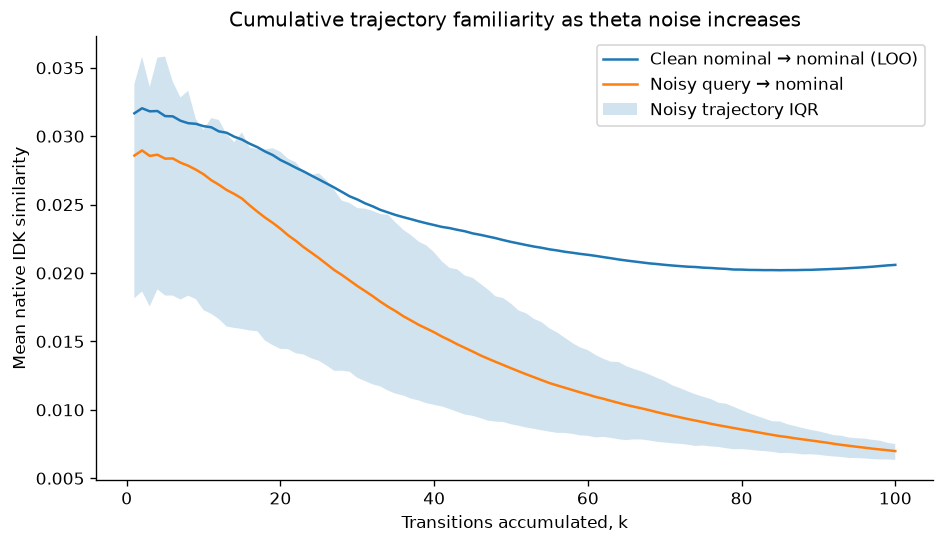

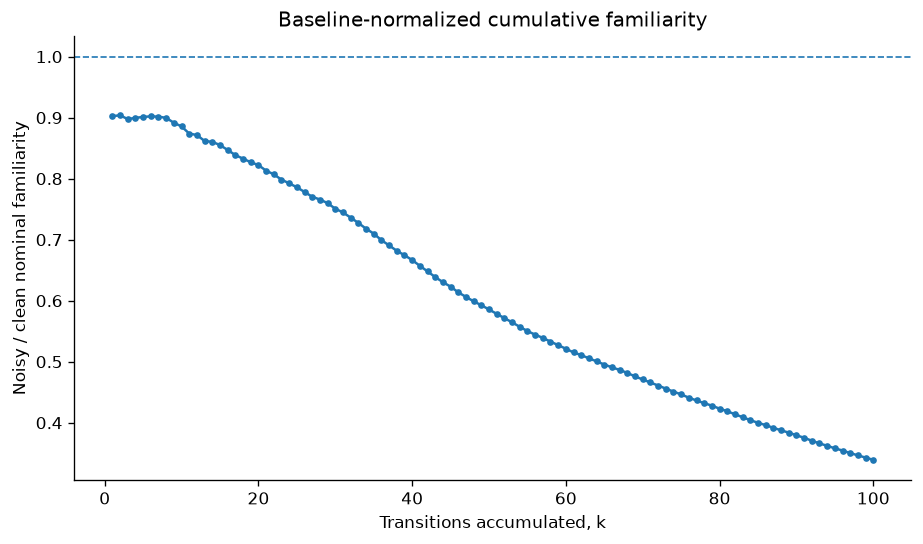

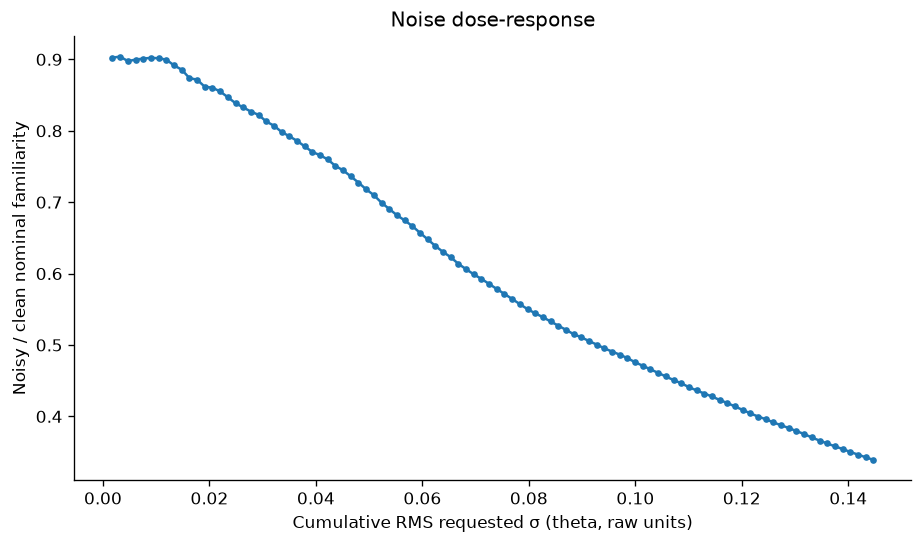

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(curve["k"], curve["clean_mean_similarity"], label="Clean nominal → nominal (LOO)")
ax.plot(curve["k"], curve["noisy_mean_similarity"], label="Noisy query → nominal")
ax.fill_between(
    curve["k"],
    curve["noisy_q25"],
    curve["noisy_q75"],
    alpha=0.2,
    label="Noisy trajectory IQR",
)
ax.set_xlabel("Transitions accumulated, k")
ax.set_ylabel("Mean native IDK similarity")
ax.set_title(f"Cumulative trajectory familiarity as {noise_dimension_name} noise increases")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(curve["k"], curve["mean_similarity_ratio"], marker="o", markersize=3)
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_xlabel("Transitions accumulated, k")
ax.set_ylabel("Noisy / clean nominal familiarity")
ax.set_title("Baseline-normalized cumulative familiarity")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(
    curve["cumulative_sigma_rms"],
    curve["mean_similarity_ratio"],
    marker="o",
    markersize=3,
)
ax.set_xlabel(f"Cumulative RMS requested σ ({noise_dimension_name}, raw units)")
ax.set_ylabel("Noisy / clean nominal familiarity")
ax.set_title("Noise dose-response")
plt.show()


## Findings

As expected, the similarity for noised trajectories decreases with time significantly more than the nominal trajectories.  We ran a number of checks to verify that the datasets appear to be behaving as expected and that we are not making any methodological mistakes.  The result of this experiment is that we gain a degree of trust in our intuition of IDK embeddings for cartpole representations.